## [1] 생성자 기본 이해하기

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import os
import numpy as np

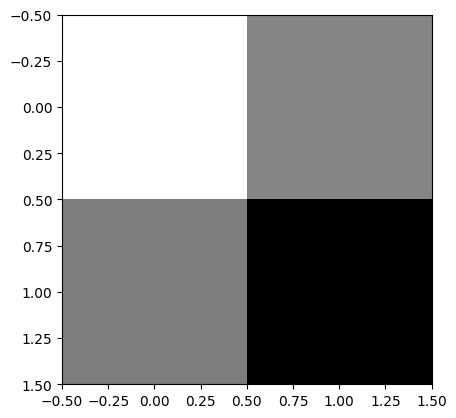

In [3]:

# 3개의 노이즈 자료. 생성자 start
input_z = torch.tensor( [0.5, -0.3, 0.8] )



# Generator 네트워크 정의 (생성기)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(3, 5),
            nn.LeakyReLU(0.2),
            nn.Linear(5, 2*2),
            nn.Tanh()  # 출력값을 [-1, 1] 범위로 맞춤
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 2, 2) #배치, 채널1, 2*2로 출력

# 동작 확인
import matplotlib.pyplot as plt
%matplotlib inline

G = Generator()
# 가짜 화상을 출력
fake_images = G(input_z)

img_transformed = fake_images[0][0].detach().numpy()
plt.imshow(img_transformed, 'gray')
plt.show()

In [4]:
#----------------------------------------------
# . Generator 내부 W, b 확인하기
# -----------------------------------------------
G = Generator()

# 첫 번째 Linear (3 → 5)
W1 = G.model[0].weight.data
b1 = G.model[0].bias.data

# 두 번째 Linear (5 → 64)
W2 = G.model[2].weight.data
b2 = G.model[2].bias.data

print("W1:", W1)
print("b1:", b1)
print("W2:", W2)
print("b2:", b2)

W1: tensor([[ 0.0762, -0.3221, -0.2734],
        [ 0.2199, -0.2722, -0.2088],
        [-0.3877, -0.3328, -0.3437],
        [ 0.2889, -0.5252,  0.5153],
        [ 0.2175,  0.1663, -0.0094]])
b1: tensor([-0.3234,  0.2513,  0.3487, -0.5297,  0.2759])
W2: tensor([[-0.4093,  0.2127, -0.1650, -0.0907, -0.2445],
        [-0.3008,  0.2487, -0.3585,  0.3977,  0.3180],
        [ 0.2415, -0.4205, -0.3090,  0.2092,  0.2356],
        [-0.4201,  0.3128,  0.1191, -0.3206, -0.0462]])
b2: tensor([ 0.2013, -0.0937,  0.1788, -0.0041])


In [5]:
# -----------------------------------
# Forward 이후 "출력값" 보기
# ----------------------------------
z = torch.randn(1, 3)   # 예: 배치 하나
out = G(z)

print("Generator Output Shape:", out.shape)
print("Generator Output Values:\n", out)

Generator Output Shape: torch.Size([1, 1, 2, 2])
Generator Output Values:
 tensor([[[[0.2014, 0.3562],
          [0.0755, 0.1256]]]], grad_fn=<ViewBackward0>)


In [6]:
# ----- 판별자
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),        # (1,2,2) → 4
            nn.Linear(4, 3),
            nn.LeakyReLU(0.2),
            nn.Linear(3, 1),
            nn.Sigmoid()         # 진짜인지 가짜인지 확률(0~1)
        )

    def forward(self, x):
        return self.model(x)

In [7]:
D = Discriminator()

# 생성된 가짜 이미지 판별
score = D(fake_images)
print("D(fake) =", score.item())

D(fake) = 0.4660492539405823


## [2] 생성자,판별자 간단이해
- 1) Discriminator(D) 학습할 때 라벨 , D는 진짜/가짜를 구분하는 모델
  - ✔ real 이미지 → label = 1   (→ real을 넣으면 1이 나오도록 D의 파라미터가 업데이트됨)
    - pred_real = D(real_img)
    - loss_real = BCE(pred_real, 1)
  - ✔ fake 이미지(G가 만든 가짜) → label = 0 (→ fake를 넣으면 0이 나오도록 D의 파라미터가 업데이트됨)
    - pred_fake = D(fake_img)
    - loss_fake = BCE(pred_fake, 0)

  - ✔ D의 총 손실
  - loss_D = loss_real + loss_fake

        # D 학습 시에는 G의 파라미터를 고정해야 함
          fake_img = G(z).detach()  # ← detach()로 G로의 gradient 차단
          pred_fake = D(fake_img)
          loss_fake = BCE(pred_fake, 0)

- 2) Generator(G) 학습할 때 라벨, G는 D를 속이려고 하는 모델 (“내가 만든 가짜(fake)를 D가 진짜(1)라고 믿게” 만들고 싶다.)
  - ✔ fake 이미지인데도 라벨을 1로 둔다
    - pred_fake = D(fake_img)
    - loss_G = BCE(pred_fake, 1)   # ← 여기 핵심
      -fake지만 1로 분류되게 G의 파라미터가 업데이트됨 → 즉 G는 “fake를 real처럼 보이게” 만드는 방향으로 학습됨
              
            # G 학습 시에는 detach() 하지 않음
            fake_img = G(z)  # ← gradient가 G까지 흘러가야 함
            pred_fake = D(fake_img)
            loss_G = BCE(pred_fake, 1)  # D를 속이는 방향으로 학습


- 마지막 feature map 역할 = 입력 x 자체(지금은 단순 모델이므로)
  - CNN이면 그 feature map이 x 대신 들어오는 것 (feature_map을 가중치 W와 내적(dot product)해서 나오는 값)
   - 이 값이 크면 진짜, 작으면 가짜
   - 이것이 D가 진짜/가짜를 판단하는 근거

In [16]:

import torch
import torch.nn as nn
import torch.optim as optim

# 1) 진짜와 가짜 이미지 정의
real_img = torch.tensor([[1.0, 0.0, 1.0]])     # 진짜
fake_img = torch.tensor([[0.2, 0.7, -0.3]])    # 가짜

# 2) Discriminator 정의 (3 입력 → 1 출력)
D = nn.Linear(3, 1, bias=True)

criterion = nn.BCELoss()
opt = optim.SGD(D.parameters(), lr=0.1)

for step in range(5):   # 5번만 돌려보자
    pred_real = torch.sigmoid(D(real_img))
    pred_fake = torch.sigmoid(D(fake_img))

    real_label = torch.ones((1,1))
    fake_label = torch.zeros((1,1))

    # 진짜라서 label=1인데 / pred가 1에 가까우면 → loss 작음
    # 가짜라서 label=0인데  / pred가 0에 가까우면 → loss 작음
    loss = criterion(pred_real, real_label) + criterion(pred_fake, fake_label)

    opt.zero_grad()
    loss.backward()
    opt.step()

    print(f"\n=== STEP {step} ===")
    print("D weights:", D.weight.data)
    print("D bias:", D.bias.data)
    print('\n')
    print("real_img:", real_img)
    print("fake_img:", fake_img)
    print('\n')

    print("logit_real = W·real + b =", D(real_img))
    print("logit_fake = W·fake + b =", D(fake_img))

    print('\n')

    print("pred_real(sigmoid(logit_real)) =", pred_real.item())
    print("pred_fake(sigmoid(logit_fake)) =", pred_fake.item())
    print("loss =", loss.item())



=== STEP 0 ===
D weights: tensor([[-0.0020, -0.0877,  0.1836]])
D bias: tensor([-0.0172])


real_img: tensor([[1., 0., 1.]])
fake_img: tensor([[ 0.2000,  0.7000, -0.3000]])


logit_real = W·real + b = tensor([[0.1644]], grad_fn=<AddmmBackward0>)
logit_fake = W·fake + b = tensor([[-0.1341]], grad_fn=<AddmmBackward0>)


pred_real(sigmoid(logit_real)) = 0.5154264569282532
pred_fake(sigmoid) = 0.4748120903968811
loss = 1.3067598342895508

=== STEP 1 ===
D weights: tensor([[ 0.0346, -0.1204,  0.2435]])
D bias: tensor([-0.0180])


real_img: tensor([[1., 0., 1.]])
fake_img: tensor([[ 0.2000,  0.7000, -0.3000]])


logit_real = W·real + b = tensor([[0.2601]], grad_fn=<AddmmBackward0>)
logit_fake = W·fake + b = tensor([[-0.1684]], grad_fn=<AddmmBackward0>)


pred_real(sigmoid(logit_real)) = 0.5409988164901733
pred_fake(sigmoid) = 0.4665139615535736
loss = 1.2426605224609375

=== STEP 2 ===
D weights: tensor([[ 0.0689, -0.1525,  0.3008]])
D bias: tensor([-0.0203])


real_img: tensor([[1., 0., 1.

## [2] Mnist_Gan

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # [-1, 1]로 정규화
])

mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
loader = DataLoader(mnist, batch_size=64, shuffle=True)


In [20]:
#---------------------------------------------
#  (100 → 784 → 28×28)
#------------------------------------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Tanh()      # MNIST도 [-1,1]로 맞추기
        )
    def forward(self, z):
        out = self.net(z)
        return out.view(-1, 1, 28, 28)


In [21]:
#----------------------------------------
# (100 → 784 → 28×28)
#--------------------------------------------
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),            # 1×28×28 → 784
            nn.Linear(784, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)



In [22]:
# 장치 설정 (GPU 사용 가능하면 GPU 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 생성기와 판별기 초기화
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

#  현재 데이터로더기:  loader = DataLoader(mnist, batch_size=64, shuffle=True)
- (배치크기, 채널, 높이, 너비) => (64, 1, 28, 28)
- 64개의 이미지임으로 노이즈데이터도 64개가 필요함. (1개의 노이즈로 64개를 사용해도 되나, 그러면 학습성능이 매우 떨어짐)

In [26]:
# ----------------------------------
# 1) 고정된 노이즈(65장 생성) 준비
# ----------------------------------
fixed_noise = torch.randn(64, 100, device=device)


# ---------------------------------------------
#  D는 진짜 → 1 /  가짜 → 0  이렇게 맞추려고 학습한다.
#  G는  가짜이미지를 D가 진짜(1)라고 하도록 속이려고 학습한다.
#   두 번의 학습 단계(D, G) 만 존재한다
# ------------------------------------------------

for epoch in range(20):

    for real, _ in loader:
        real = real.to(device)

        batch = real.shape[0]  # real.size(0)


        # ----- 1) Discriminator: real=1, fake=0 -----
        z = torch.randn(batch, 100, device=device)
        fake = G(z)

        pred_real = D(real)
        pred_fake = D(fake.detach())

        loss_D_real = criterion(
            pred_real,
            torch.ones(batch, 1, device=device)
        ) # D(진짜이미지) 를 1로 만들기


        loss_D_fake = criterion(
            pred_fake,
            torch.zeros(batch, 1, device=device)
        )
        loss_D = loss_D_real + loss_D_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ----- 2) Generator: want D(fake)=1 -----
        z = torch.randn(batch, 100, device=device)
        fake = G(z)

        pred_fake = D(fake)
        loss_G = criterion(
            pred_fake,
            torch.ones(batch, 1, device=device)        \
        )

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()


    print("epoch done")


epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done
epoch done


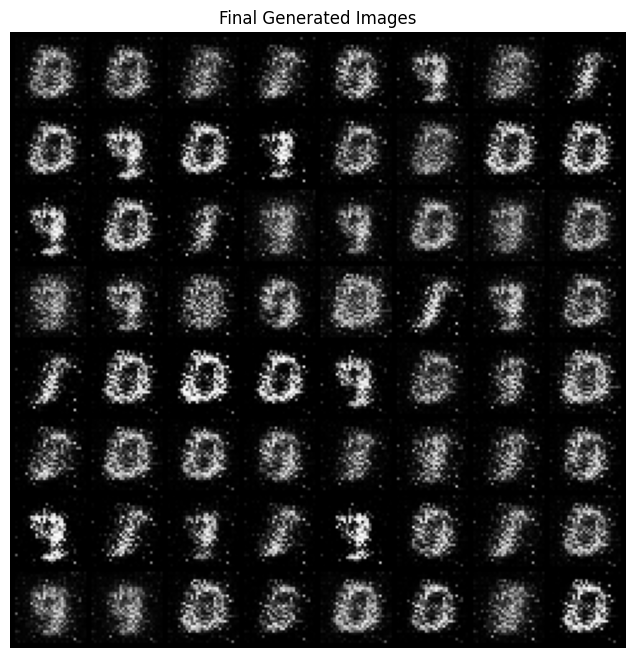

In [30]:

# 마지막 에포크에서 생성된 이미지 그리드 출력
with torch.no_grad():
    fake_images = G(fixed_noise).detach().cpu()
grid = utils.make_grid(fake_images, nrow=8, normalize=True)
plt.figure(figsize=(8,8))
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.title('Final Generated Images')
plt.axis('off')
plt.show()
